<h2 style='color:blue' align="center">Decision Tree Classification</h2>

In [1]:

import pandas as pd

import warnings
warnings.filterwarnings('ignore')

In [2]:

df = pd.read_csv("salaries.csv")
df

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0
5,google,computer programmer,masters,1
6,abc pharma,sales executive,masters,0
7,abc pharma,computer programmer,bachelors,0
8,abc pharma,business manager,bachelors,0
9,abc pharma,business manager,masters,1


In [3]:

inputs = df.drop('salary_more_then_100k',axis='columns')

In [4]:
inputs

,company,job,degree
0,google,sales executive,bachelors
1,google,sales executive,masters
2,google,business manager,bachelors
3,google,business manager,masters
4,google,computer programmer,bachelors
5,google,computer programmer,masters
6,abc pharma,sales executive,masters
7,abc pharma,computer programmer,bachelors
8,abc pharma,business manager,bachelors
9,abc pharma,business manager,masters


In [5]:
target = df['salary_more_then_100k']

In [6]:
target

0     0
1     0
2     1
3     1
4     0
5     1
6     0
7     0
8     0
9     1
10    1
11    1
12    1
13    1
14    1
15    1
Name: salary_more_then_100k, dtype: int64

In [7]:
from sklearn.preprocessing import LabelEncoder

le_company = LabelEncoder()
le_job = LabelEncoder()
le_degree = LabelEncoder()

In [8]:
inputs['company_n'] = le_company.fit_transform(inputs['company'])
inputs['job_n'] = le_job.fit_transform(inputs['job'])
inputs['degree_n'] = le_degree.fit_transform(inputs['degree'])

In [9]:
inputs

,company,job,degree,company_n,job_n,degree_n
0,google,sales executive,bachelors,2,2,0
1,google,sales executive,masters,2,2,1
2,google,business manager,bachelors,2,0,0
3,google,business manager,masters,2,0,1
4,google,computer programmer,bachelors,2,1,0
5,google,computer programmer,masters,2,1,1
6,abc pharma,sales executive,masters,0,2,1
7,abc pharma,computer programmer,bachelors,0,1,0
8,abc pharma,business manager,bachelors,0,0,0
9,abc pharma,business manager,masters,0,0,1


In [10]:
inputs_n = inputs.drop(['company','job','degree'],axis='columns')

In [11]:
inputs_n

,company_n,job_n,degree_n
0,2,2,0
1,2,2,1
2,2,0,0
3,2,0,1
4,2,1,0
5,2,1,1
6,0,2,1
7,0,1,0
8,0,0,0
9,0,0,1


In [12]:
target

0     0
1     0
2     1
3     1
4     0
5     1
6     0
7     0
8     0
9     1
10    1
11    1
12    1
13    1
14    1
15    1
Name: salary_more_then_100k, dtype: int64

In [13]:
from sklearn import tree
model = tree.DecisionTreeClassifier(criterion='entropy')

In [14]:
model.fit(inputs_n, target)

DecisionTreeClassifier(criterion='entropy')

In [15]:
model.score(inputs_n,target)

1.0

**Is salary of Google, Computer Engineer, Bachelors degree > 100 k ?**

In [16]:
print(le_company.classes_)  
print(le_job.classes_)      
print(le_degree.classes_)   

['abc pharma' 'facebook' 'google']
['business manager' 'computer programmer' 'sales executive']
['bachelors' 'masters']


In [17]:
model.predict([[2,1,0]])

array([0], dtype=int64)

**Is salary of Google, Computer Engineer, Masters degree > 100 k ?**

In [18]:
model.predict([[2,1,1]])

array([1], dtype=int64)

### Draw Tree

In [19]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

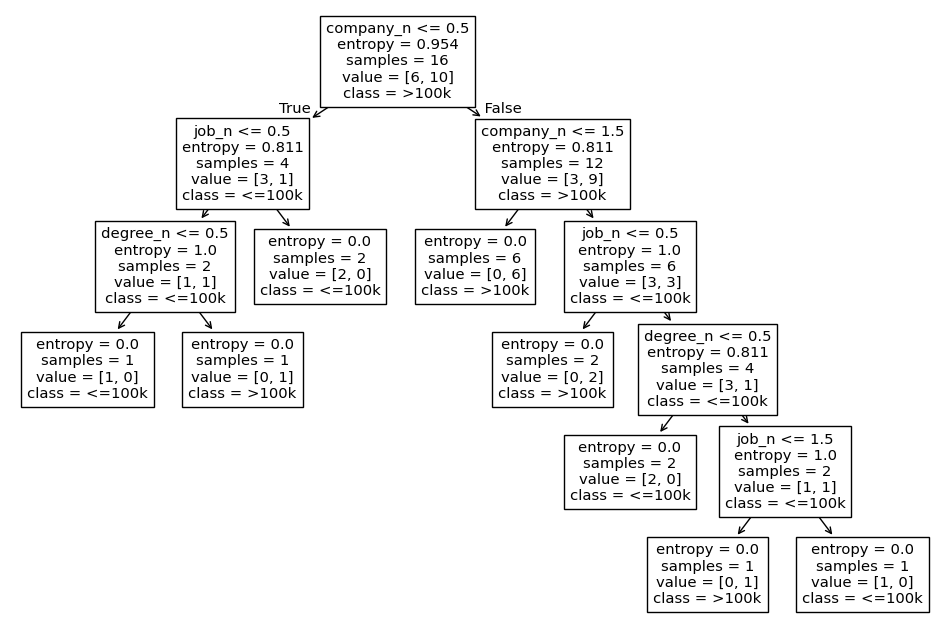

In [20]:
plt.figure(figsize=(12, 8))
plot_tree(
    model,
    feature_names=['company_n', 'job_n', 'degree_n'],
    class_names=['<=100k', '>100k'],
)
plt.show()

# ver 2

In [ ]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv("salaries.csv")
print(df.head())


In [ ]:
X = df[['company', 'job', 'degree']]
y = df['salary_more_then_100k']


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ['company', 'job', 'degree']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(criterion='entropy', random_state=42))
])

model.fit(X_train, y_train)

train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("\nTraining Accuracy:", round(train_acc, 3))
print("Testing Accuracy:", round(test_acc, 3))


In [ ]:
def predict_salary(company, job, degree):
    sample = pd.DataFrame([[company, job, degree]],
                          columns=['company', 'job', 'degree'])
    
    pred = model.predict(sample)[0]
    
    if pred == 1:
        return "Salary > 100k"
    else:
        return "Salary ≤ 100k"


In [ ]:
print("\nPrediction 1:")
print("Google, Computer Engineer, Bachelors →", 
      predict_salary("Google", "Computer Engineer", "Bachelors"))

print("\nPrediction 2:")
print("Google, Computer Engineer, Masters →", 
      predict_salary("Google", "Computer Engineer", "Masters"))
